## zeroshot/twitter-financial-news-sentiment

In [2]:
import pandas as pd

splits = {'train': 'sent_train.csv', 'validation': 'sent_valid.csv'}
df_train_twitter = pd.read_csv("hf://datasets/zeroshot/twitter-financial-news-sentiment/" + splits["train"])
df_validation_twitter = pd.read_csv("hf://datasets/zeroshot/twitter-financial-news-sentiment/" + splits["validation"])

df_train_twitter = df_train_twitter[df_train_twitter['label'] < 2]
df_validation_twitter = df_validation_twitter[df_validation_twitter['label'] < 2]

c:\Users\hique\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_twitter['text'], df_train_twitter['label'])
y_pred = pipeline.predict(df_validation_twitter['text'])
report = classification_report(df_validation_twitter['label'], y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.82      0.68      0.74       347
           1       0.79      0.89      0.84       475

    accuracy                           0.80       822
   macro avg       0.80      0.78      0.79       822
weighted avg       0.80      0.80      0.80       822



## fancyzhx/yelp_polarity

In [4]:
import pandas as pd

base = "hf://datasets/fancyzhx/yelp_polarity/"
splits = {
    "train": "plain_text/train-00000-of-00001.parquet",
    "test": "plain_text/test-00000-of-00001.parquet",
}

df_train = pd.read_parquet(base + splits["train"])
df_test = pd.read_parquet(base + splits["test"])

In [5]:

pipeline.fit(df_train['text'], df_train['label'])
y_pred = pipeline.predict(df_test['text'])
report = classification_report(df_test['label'], y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.94      0.94      0.94     19000
           1       0.94      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000



## IMDB Reviews

In [6]:
import pandas as pd

train_df_imdb = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/train-00000-of-00001.parquet")
test_df_imdb = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/test-00000-of-00001.parquet")

pipeline.fit(train_df_imdb['text'], train_df_imdb['label'])
y_pred = pipeline.predict(test_df_imdb['text'])
report = classification_report(test_df_imdb['label'], y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



# Cross Validations

In [7]:
datasets_train = {
    'imdb': train_df_imdb,
    'yelp': df_train,
    'twitter': df_train_twitter
}

datasets_tests = {
    'imdb': test_df_imdb,
    'yelp': df_test,
    'twitter': df_validation_twitter
}

acurracys = {}

for dataset_name in datasets_train.keys():
    train_df = datasets_train[dataset_name]
    for dataset_tests_name in datasets_tests.keys():
        test_df = datasets_tests[dataset_tests_name]
        pipeline.fit(train_df['text'], train_df['label'])
        y_pred = pipeline.predict(test_df['text'])
        report = classification_report(test_df['label'], y_pred, output_dict=True)
        if dataset_name not in acurracys:
            acurracys[dataset_name] = {}
        acurracys[dataset_name][dataset_tests_name] = report['accuracy']

print(acurracys)


{'imdb': {'imdb': 0.88292, 'yelp': 0.8393947368421053, 'twitter': 0.5182481751824818}, 'yelp': {'imdb': 0.83112, 'yelp': 0.9379736842105263, 'twitter': 0.5523114355231143}, 'twitter': {'imdb': 0.5154, 'yelp': 0.5687368421052632, 'twitter': 0.7992700729927007}}


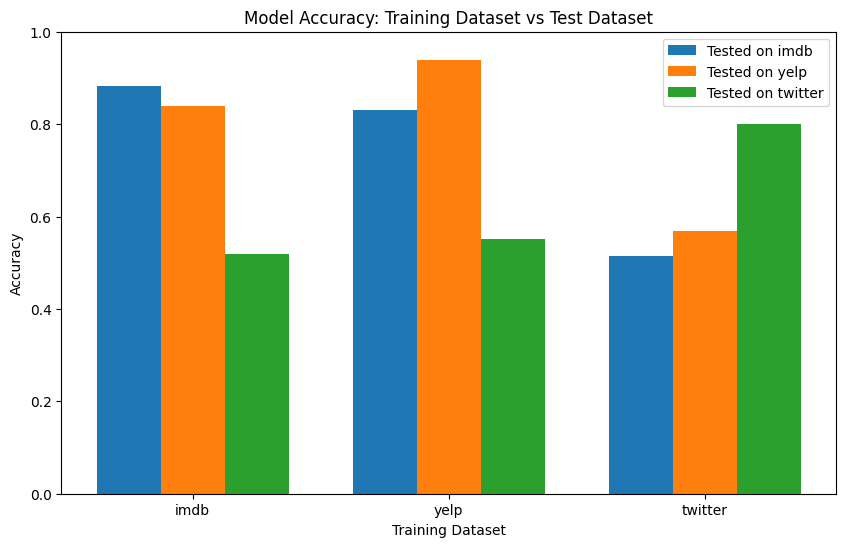

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique datasets
train_datasets = list(acurracys.keys())
test_datasets = list(acurracys[list(acurracys.keys())[0]].keys())

x = np.arange(len(train_datasets))
width = 0.25  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each test dataset with different colors
for i, test_name in enumerate(test_datasets):
    accuracies = [acurracys[train_name][test_name] for train_name in train_datasets]
    ax.bar(x + i * width, accuracies, width, label=f'Tested on {test_name}')

ax.set_xlabel('Training Dataset')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Training Dataset vs Test Dataset')
ax.set_xticks(x + width)
ax.set_xticklabels(train_datasets)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

Hard -> Treina em 3 treinos e testa em qualquer um desses testes

Very Hard -> Treina em 2 treinos e testa em um teste de um dataset que não foi usado no treino

# Challenges

## Medium

In [9]:
# Limiting Dataset Size to the Smallest Dataset 

smallest_size = min(len(train_df_imdb), len(df_train), len(df_train_twitter))

# Limit all datasets to the smallest size
train_df_imdb_undersized = train_df_imdb.sample(n=smallest_size, random_state=42)
df_train_undersized = df_train.sample(n=smallest_size, random_state=42)
df_train_twitter_undersized = df_train_twitter.sample(n=smallest_size, random_state=42)

datasets_train_small = {
    'imdb': train_df_imdb_undersized,
    'yelp': df_train_undersized,
    'twitter': df_train_twitter_undersized
}

datasets_tests_small = {
    'imdb': test_df_imdb,
    'yelp': df_test,
    'twitter': df_validation_twitter
}

accuracys_small = {}

for dataset_name in datasets_train_small.keys():
    train_df = datasets_train_small[dataset_name]
    for dataset_tests_name in datasets_tests_small.keys():
        test_df = datasets_tests_small[dataset_tests_name]
        pipeline.fit(train_df['text'], train_df['label'])
        y_pred = pipeline.predict(test_df['text'])
        report = classification_report(test_df['label'], y_pred, output_dict=True)
        if dataset_name not in accuracys_small:
            accuracys_small[dataset_name] = {}
        accuracys_small[dataset_name][dataset_tests_name] = report['accuracy']

print(accuracys_small)

{'imdb': {'imdb': 0.84384, 'yelp': 0.8135263157894737, 'twitter': 0.5802919708029197}, 'yelp': {'imdb': 0.75688, 'yelp': 0.881, 'twitter': 0.5389294403892944}, 'twitter': {'imdb': 0.5154, 'yelp': 0.5687368421052632, 'twitter': 0.7992700729927007}}


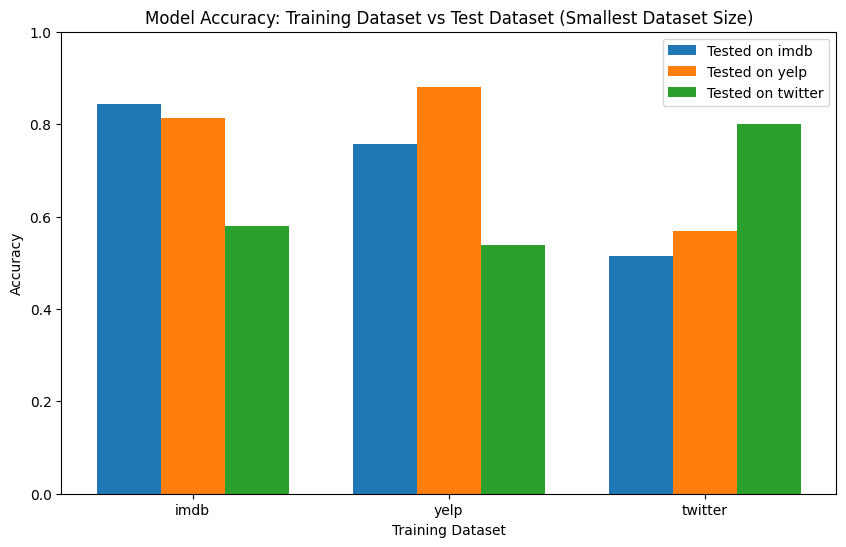

In [10]:
#plot 
# Get unique datasets
train_datasets = list(accuracys_small.keys())
test_datasets = list(accuracys_small[list(accuracys_small.keys())[0]].keys())

x = np.arange(len(train_datasets))
width = 0.25  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each test dataset with different colors
for i, test_name in enumerate(test_datasets):
    accuracies = [accuracys_small[train_name][test_name] for train_name in train_datasets]
    ax.bar(x + i * width, accuracies, width, label=f'Tested on {test_name}')

ax.set_xlabel('Training Dataset')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Training Dataset vs Test Dataset (Smallest Dataset Size)')
ax.set_xticks(x + width)
ax.set_xticklabels(train_datasets)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

## Hard

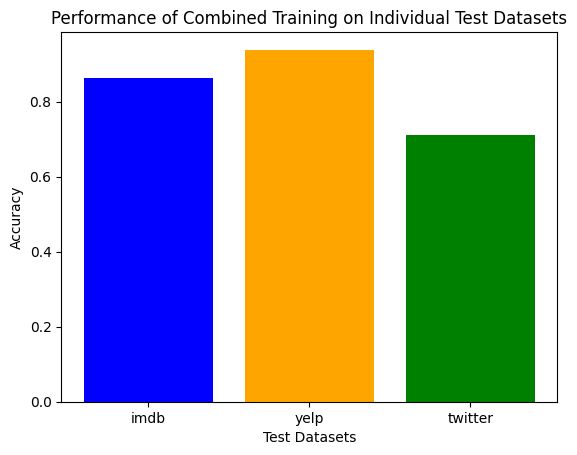

In [11]:
#Normalize datasets to train on the three datasets together and test on only one tests of those datasets

train_dataset_combined = pd.concat([train_df_imdb, df_train, df_train_twitter], ignore_index=True)  

pipeline.fit(train_dataset_combined['text'], train_dataset_combined['label'])

datasets_tests = {
    "imdb": test_df_imdb,
    "yelp": df_test,
    "twitter": df_validation_twitter
}

accuracy_hard =  {}

for dataset_tests_name in datasets_tests.keys():
    test_df = datasets_tests[dataset_tests_name]
    y_pred = pipeline.predict(test_df['text'])
    report = classification_report(test_df['label'], y_pred, output_dict=True)
    accuracy_hard[dataset_tests_name] = report['accuracy']

#Generate a bar plot for the accuracies of the combined training dataset tested on each individual test dataset

plt.bar(accuracy_hard.keys(), accuracy_hard.values(), color=['blue', 'orange', 'green'])
plt.xlabel('Test Datasets')
plt.ylabel('Accuracy')
plt.title('Performance of Combined Training on Individual Test Datasets')
plt.show()


## Very Hard

Very Hard -> Treina em 2 treinos e testa em um teste de um dataset que não foi usado no treino

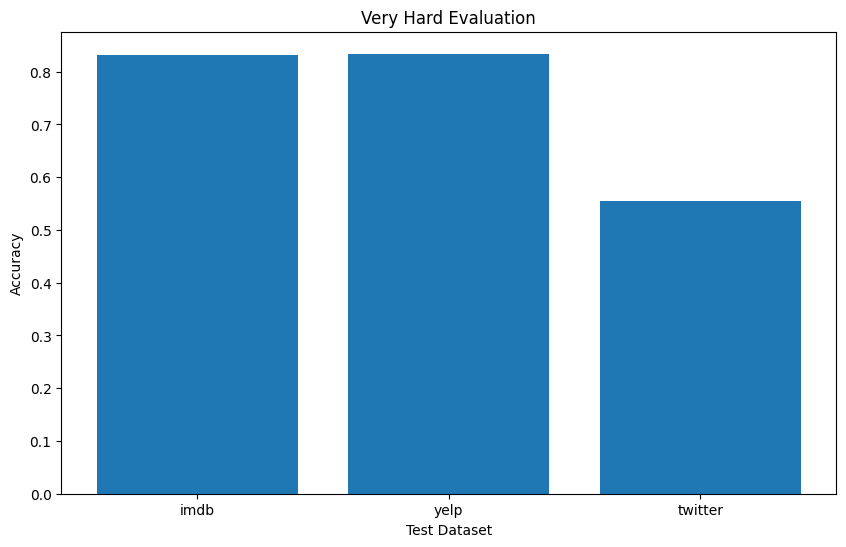

In [ ]:
train_datasets = {
    "imdb": train_df_imdb,
    "yelp": df_train,
    "twitter": df_train_twitter
}

tests_datasets = {
    "imdb": test_df_imdb,
    "yelp": df_test,
    "twitter": df_validation_twitter
}

accuracies_very_hard = {}
# Treina em todos os 2 datases e testa no que nao estiver
for train_name in train_datasets.keys():
    # Combine the other two datasets for training
    combined_train = pd.concat([df for name, df in train_datasets.items() if name != train_name], ignore_index=True)
    
    # Fit the model on the combined training data
    pipeline.fit(combined_train['text'], combined_train['label'])
    
    # Test on the dataset that was not used for training
    test_df = tests_datasets[train_name]
    y_pred = pipeline.predict(test_df['text'])
    report = classification_report(test_df['label'], y_pred, output_dict=True)
    accuracies_very_hard[train_name] = report['accuracy']



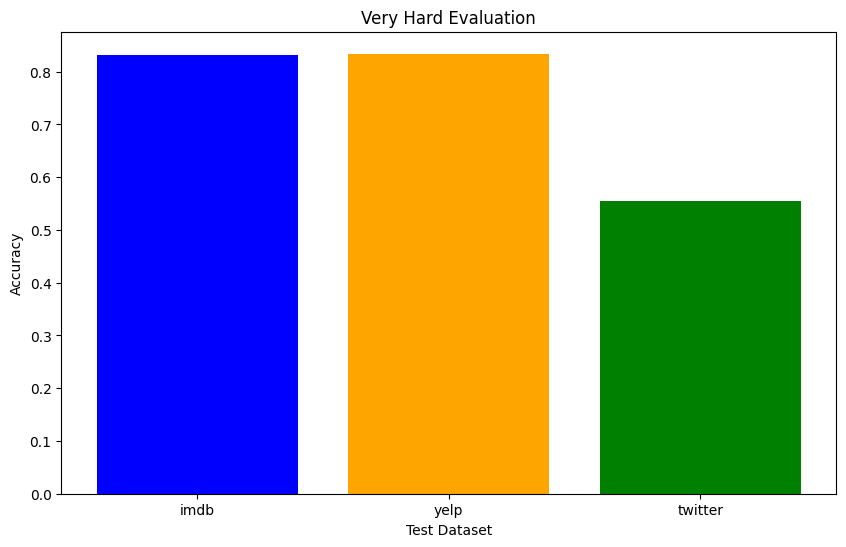

In [13]:
# Create a bar plot for the accuracies of the very hard evaluation
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(accuracies_very_hard.keys(), accuracies_very_hard.values(), color=['blue', 'orange', 'green'])
plt.xlabel('Test Dataset')
plt.ylabel('Accuracy')
plt.title('Very Hard Evaluation')
plt.show()


In [14]:
accuracies_very_hard

{'imdb': 0.831, 'yelp': 0.8341052631578947, 'twitter': 0.5547445255474452}